In [1]:
import sys
from pathlib import Path

BASE_DIR = Path().resolve().parent
DATA_DIR = BASE_DIR / 'datasets' / 'ptb-xl'
CLEAN_DATA_DIR = DATA_DIR / 'data_clean'

sys.path.append(str(BASE_DIR))

In [ ]:
import os
import ast

import pandas as pd
import numpy as np
from scipy.signal import butter, filtfilt
import wfdb

In [3]:
def load_ptbxl_metadata(data_dir):
    print("Loading and parsing CSV metadata...")
    df = pd.read_csv(data_dir / 'ptbxl_database.csv', index_col='ecg_id')
    df.scp_codes = df.scp_codes.apply(lambda x: ast.literal_eval(x))
    
    agg_df = pd.read_csv(data_dir / 'scp_statements.csv', index_col=0)
    agg_df = agg_df[agg_df.diagnostic == 1]
    
    def aggregate_diagnostic(y_dic):
        tmp = np.zeros(4)
        mapping = {'MI': 0, 'STTC': 1, 'CD': 2, 'HYP': 3}
        for key in y_dic.keys():
            if key in agg_df.index:
                superclass = agg_df.loc[key].diagnostic_class
                if superclass in mapping:
                    tmp[mapping[superclass]] = 1.0
        return tmp

    df['diagnostic_labels'] = df.scp_codes.apply(aggregate_diagnostic)
    
    print(f"Total samples before filtering: {len(df)}")
    valid_diagnostic_codes = set(agg_df.index)
    df = df[df.scp_codes.apply(lambda x: any(code in valid_diagnostic_codes for code in x.keys()))]
    print(f"Total samples after filtering:  {len(df)}")
    return df

def preprocess_signal(raw_signal, fs=100.0):
    nyq = 0.5 * fs
    low = 1.0 / nyq
    high = 45.0 / nyq
    b, a = butter(N=2, Wn=[low, high], btype='band')
    
    filtered_signal = filtfilt(b, a, raw_signal, axis=0)
    
    mean = np.mean(filtered_signal, axis=0)
    std = np.std(filtered_signal, axis=0) + 1e-8
    normalized_signal = (filtered_signal - mean) / std
    
    return normalized_signal.T.astype(np.float32)

def preprocess_and_save_dataset():
    df = load_ptbxl_metadata(DATA_DIR)
    os.makedirs(CLEAN_DATA_DIR, exist_ok=True)
    
    splits = {
        'train': df[df.strat_fold <= 8],
        'val': df[df.strat_fold == 9],
        'test': df[df.strat_fold == 10]
    }
    
    print("\n--- Starting ECG Signal Preprocessing (All 12 Leads) ---")
    
    for split_name, split_df in splits.items():
        print(f"\nProcessing '{split_name}' split ({len(split_df)} samples)...")
        file_names = split_df.filename_lr.values
        labels_list = np.vstack(split_df.diagnostic_labels.values).astype(np.float32)
        signals_list = []
        
        for idx, filename in enumerate(file_names):
            file_path = os.path.join(DATA_DIR, filename)
            record, _ = wfdb.rdsamp(file_path)
            clean_signal = preprocess_signal(record)
            signals_list.append(clean_signal)
            
            if (idx + 1) % 1000 == 0 or (idx + 1) == len(file_names):
                print(f"  Processed {idx + 1}/{len(file_names)} samples...")
                
        signals_array = np.array(signals_list, dtype=np.float32)
        
        x_path = os.path.join(CLEAN_DATA_DIR, f'{split_name}_x.npy')
        y_path = os.path.join(CLEAN_DATA_DIR, f'{split_name}_y.npy')
        
        np.save(x_path, signals_array)
        np.save(y_path, labels_list)
        
        print(f"Saved {split_name} -> X: {signals_array.shape}, Y: {labels_list.shape}")

    print("\nPreprocessing finished successfully.")

preprocess_and_save_dataset()

Loading and parsing CSV metadata...
Total samples before filtering: 21799
Total samples after filtering:  21388

--- Starting ECG Signal Preprocessing (All 12 Leads) ---

Processing 'train' split (17084 samples)...
  Processed 1000/17084 samples...
  Processed 2000/17084 samples...
  Processed 3000/17084 samples...
  Processed 4000/17084 samples...
  Processed 5000/17084 samples...
  Processed 6000/17084 samples...
  Processed 7000/17084 samples...
  Processed 8000/17084 samples...
  Processed 9000/17084 samples...
  Processed 10000/17084 samples...
  Processed 11000/17084 samples...
  Processed 12000/17084 samples...
  Processed 13000/17084 samples...
  Processed 14000/17084 samples...
  Processed 15000/17084 samples...
  Processed 16000/17084 samples...
  Processed 17000/17084 samples...
  Processed 17084/17084 samples...
Saved train -> X: (17084, 12, 1000), Y: (17084, 4)

Processing 'val' split (2146 samples)...
  Processed 1000/2146 samples...
  Processed 2000/2146 samples...
  Pro

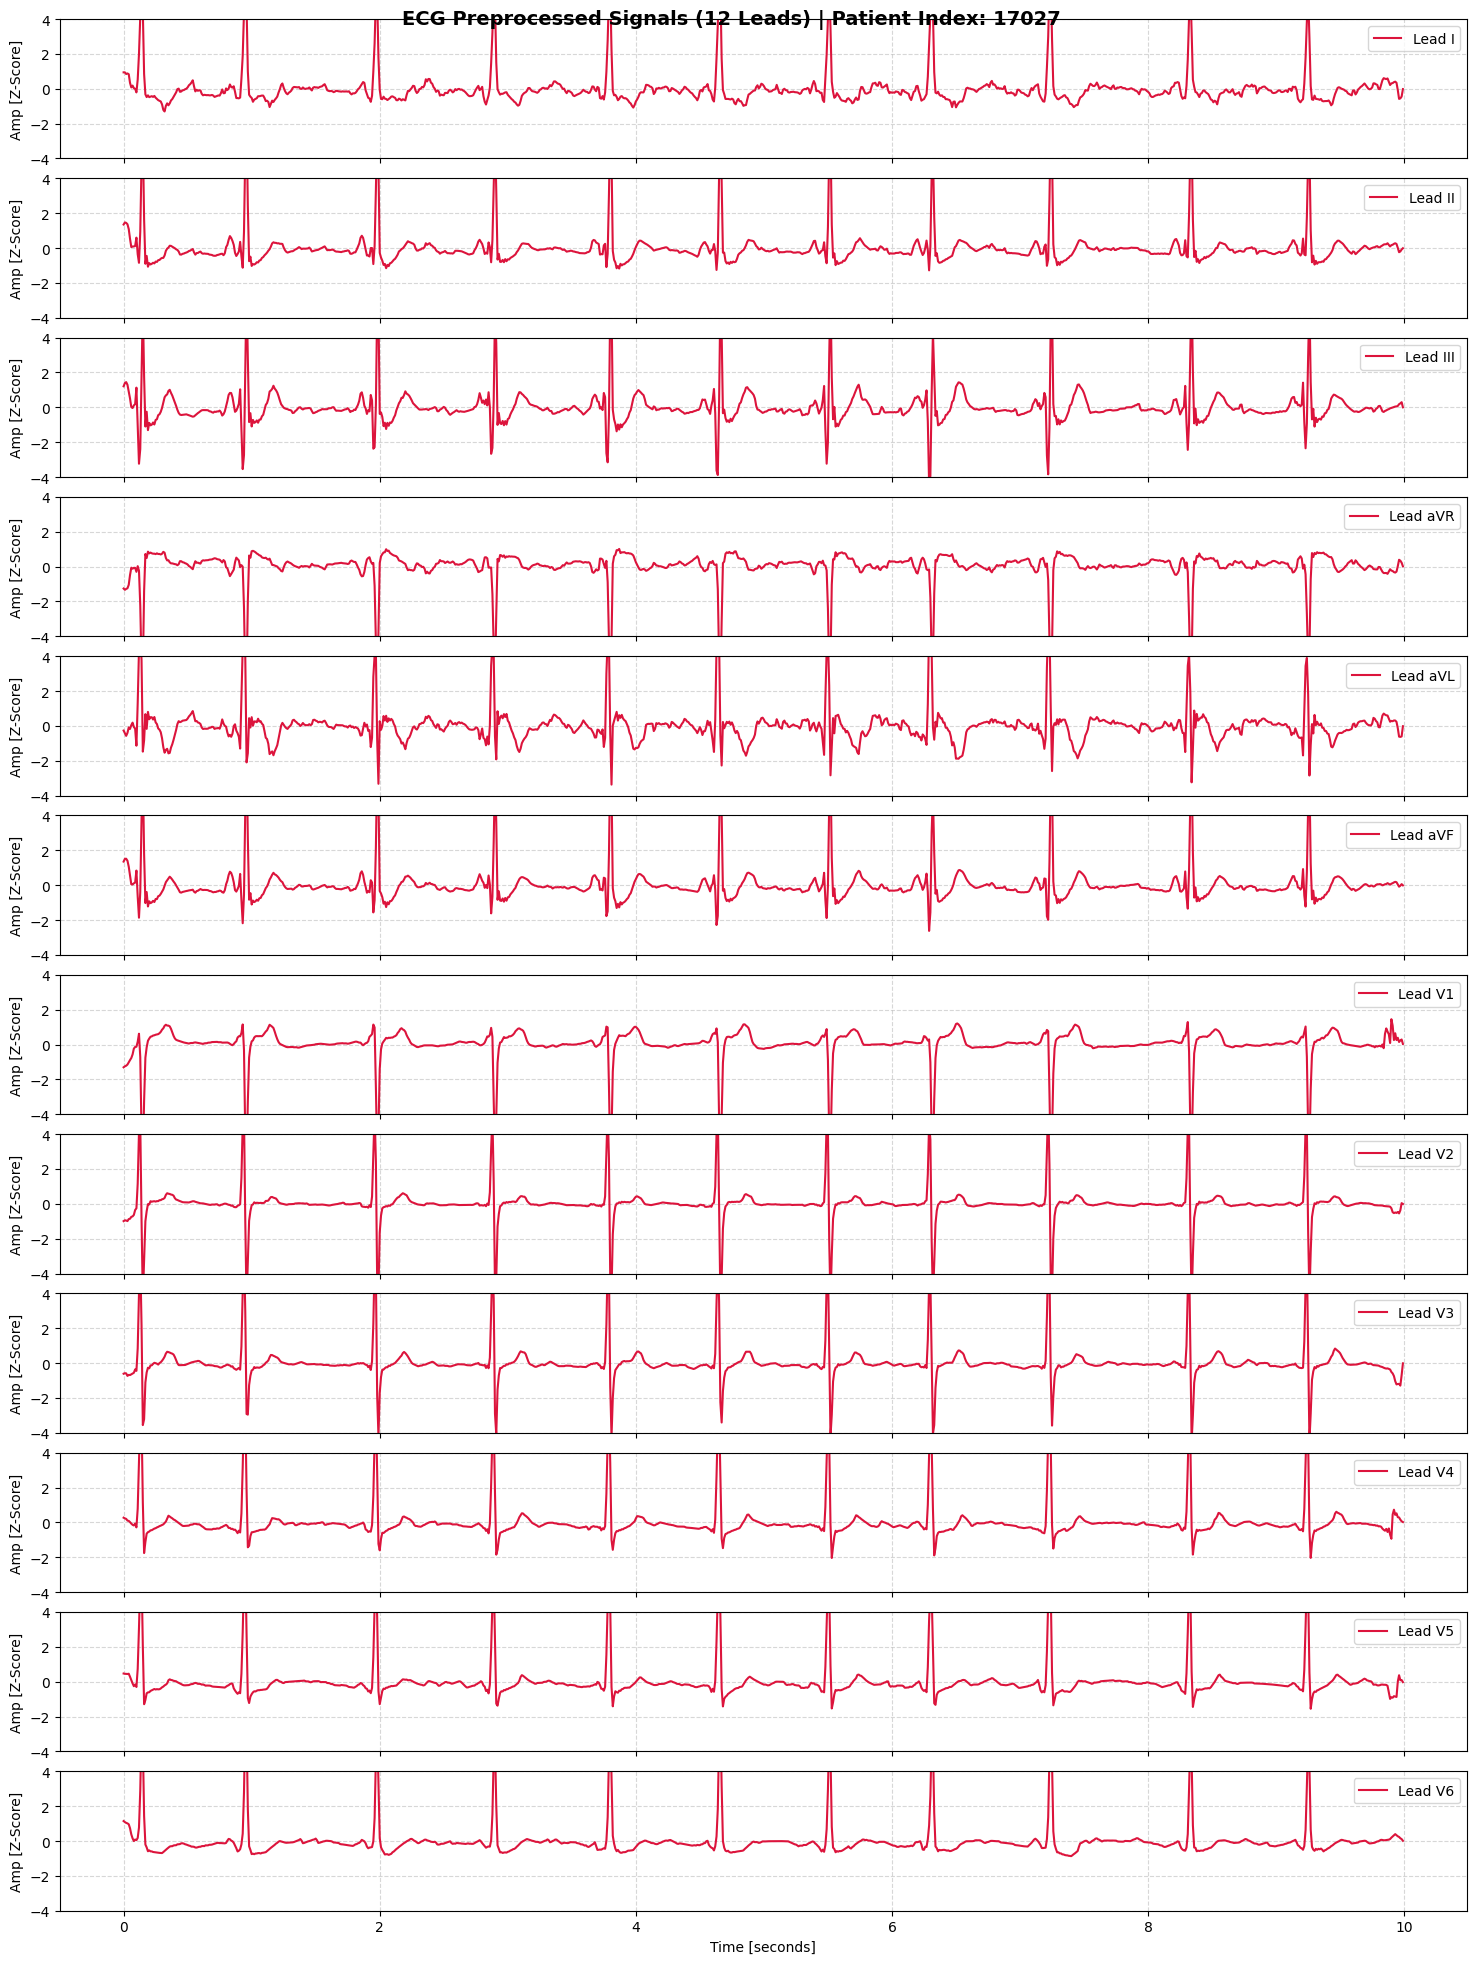

In [4]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

signals = np.load(os.path.join(CLEAN_DATA_DIR, 'train_x.npy'))

fs = 100.0  
num_samples = 1000  
time_axis = [i / fs for i in range(num_samples)]

leads_names = ["I", "II", "III", "aVR", "aVL", "aVF", "V1", "V2", "V3", "V4", "V5", "V6"]

random_idx = random.randint(0, len(signals) - 1)
patient_signals = signals[random_idx] 

fig, axes = plt.subplots(12, 1, figsize=(15, 20), sharex=True)
fig.suptitle(f"ECG Preprocessed Signals (12 Leads) | Patient Index: {random_idx}", fontsize=14, fontweight='bold')

for i in range(12):
    ax = axes[i]
    ax.plot(time_axis, patient_signals[i, :], color='crimson', label=f'Lead {leads_names[i]}')
    
    ax.set_ylabel("Amp [Z-Score]")
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper right')
    ax.set_ylim(-4, 4)

axes[-1].set_xlabel("Time [seconds]")

plt.tight_layout()
plt.show()